# 01. Bias Detection in Machine Learning Models

## 📚 Learning Objectives

By completing this notebook, you will:
- Detect bias in datasets and model outputs
- Use metrics and visualizations to assess fairness
- Identify sources of discriminatory impact

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

---

# 01. Bias Detection in Machine Learning Models

## 🚨 THE PROBLEM: AI Systems Are Making Unfair Decisions

**Remember the COMPAS case study from Unit 1?**

We discovered that COMPAS showed:
- Higher false positive rates for Black defendants
- Higher false negative rates for White defendants
- Racial bias in risk predictions

**The Problem**: We understand ethics foundations, but **AI systems show bias. How do we detect it?**

**We've learned:**
- ✅ How to identify ethical issues (frameworks from Unit 1)
- ✅ How bias manifests in real systems (COMPAS case study)
- ✅ That bias is a serious ethical problem

**But we haven't learned:**
- ❌ How to **detect** bias in AI systems
- ❌ How to **measure** bias quantitatively
- ❌ How to **identify** where bias exists

**We need bias detection tools** to:
1. Find where bias exists in our models
2. Measure how unfair our systems are
3. Identify which groups are being discriminated against

**This notebook solves that problem** by teaching you bias detection metrics and tools!

---

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Unit 1: Foundations of AI Ethics** - You need to understand ethical frameworks and case studies!
- ✅ **Basic Python knowledge**: Functions, dictionaries, data manipulation
- ✅ **Basic ML knowledge**: Classification, train/test split, confusion matrices
- ✅ **Understanding of bias**: What is algorithmic bias? (from Unit 1 case studies)

**If you haven't completed these**, you might struggle with:
- Understanding why bias detection matters
- Knowing which metrics to use for bias detection
- Interpreting bias detection results

---

## 🔗 Where This Notebook Fits

**This is the FIRST example in Unit 2** - it addresses the problem from Unit 1!

**Why this example FIRST?**
- **Before** you can mitigate bias, you need to detect it (addresses the problem!)
- **Before** you can ensure fairness, you need to measure it
- **Before** you can fix problems, you need to identify them

**Builds on**: 
- 📓 Unit 1: Foundations (we identified bias as a problem - now we learn to detect it!)

**Leads to**: 
- 📓 Example 2: Bias Mitigation (once we detect bias, we learn to fix it!)
- 📓 Example 3: Fair Representation (ensuring fair representation in data)
- 📓 Example 4: Bias Case Studies (analyzing real bias cases)
- 📓 Example 5: Fair AI Development (building fair AI systems)

**Why this order?**
1. Detection **addresses the problem** from Unit 1 (we need to detect bias!)
2. Detection provides **measurement tools** (needed before mitigation)
3. Detection teaches **what bias looks like** (critical for understanding)

---

## The Story: Finding the Problem Before Fixing It

Imagine you're a doctor diagnosing a patient. **Before** you can treat an illness, you need to diagnose it - run tests, check symptoms, identify the problem. **After** diagnosis, you can prescribe the right treatment!

Same with AI bias: **Before** we can fix bias, we need to detect it - measure fairness metrics, check for disparities, identify where bias exists. **After** detection, we can apply the right mitigation strategies!

---

## Why Bias Detection Matters

Bias detection is essential for ethical AI:
- **Identify Problems**: Find where bias exists in your models
- **Measure Fairness**: Quantify how fair (or unfair) your system is
- **Track Progress**: Monitor if bias mitigation efforts are working
- **Ensure Compliance**: Meet fairness requirements and regulations
- **Build Trust**: Demonstrate commitment to fairness

## Learning Objectives
1. Understand different types of bias in ML models
2. Learn fairness metrics (demographic parity, equalized odds)
3. Detect bias using statistical measures
4. Visualize bias in model predictions
5. Interpret bias detection results
6. Understand when to use different fairness metrics

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- `../../../Course 04/datasets/raw/titanic.csv` - the real Titanic passenger manifest
  (891 real passengers; `Age` has 177 genuine missing values, `Embarked` has 2).
- `Sex` is the protected attribute we audit; `Pclass` is a real socio-economic attribute.

**Outputs:** What you'll see when you run the cells

- The real survival gap by sex and by ticket class
- Demographic parity, equalized odds and per-group accuracy for a trained model
- Charts comparing the historical record against the model's predictions

---

In [1]:
# Step 1: Import necessary libraries
# These libraries help us detect bias in machine learning models

import matplotlib.pyplot as plt  # For creating visualizations: Charts, graphs, bias visualizations
import numpy as np  # For numerical operations: Arrays, calculations, random number generation
import pandas as pd  # For data manipulation: DataFrames, data analysis
from sklearn.model_selection import train_test_split  # For splitting data: Separate training and testing sets
from sklearn.ensemble import RandomForestClassifier  # For ML model: Classification algorithm
from sklearn.metrics import confusion_matrix, classification_report  # For model evaluation: Performance metrics
import seaborn as sns  # For statistical visualizations: Heatmaps, advanced plots
import os  # For file operations: Saving images

# Configure matplotlib settings: Set default figure size and font size for better visualizations
plt.rcParams['font.size'] = 10  # Font size: Make text readable (10pt is good for most displays)
plt.rcParams['figure.figsize'] = (14, 8)  # Figure size: 14 inches wide, 8 inches tall (good for detailed charts)

print(" Libraries imported successfully!")
print("\n📚 What each library does:")
print("   - matplotlib/seaborn: Create visualizations (bias charts, heatmaps)")
print("   - numpy: Numerical operations (arrays, calculations)")
print("   - pandas: Data manipulation (DataFrames, analysis)")
print("   - sklearn: Machine learning (models, metrics, data splitting)")
print("   - os: File operations (saving images)")


 Libraries imported successfully!

📚 What each library does:
   - matplotlib/seaborn: Create visualizations (bias charts, heatmaps)
   - numpy: Numerical operations (arrays, calculations)
   - pandas: Data manipulation (DataFrames, analysis)
   - sklearn: Machine learning (models, metrics, data splitting)
   - os: File operations (saving images)


## Part 2: Meeting Real Bias in Real Data

### 📚 Prerequisites (What You Need First)
- **Library imports** (from Part 1) - Understanding data manipulation and ML tools
- **Understanding of bias** (from Unit 1) - Knowing what bias is

### 🔗 Relationship: What This Builds On
This loads a REAL historical dataset in which a real, documented disparity exists,
so we practice detection on evidence rather than on invented people.
- Builds on: Data manipulation skills, understanding of bias
- Shows: How disparity actually looks in a real record

### 📖 The Story
**Before the data**: We need a case where a group difference genuinely exists.
**After the data**: We have the Titanic passenger manifest - 891 real people, a real
life-and-death decision ("who got a place in a lifeboat"), and a survival gap between
women and men so large that no simulation is needed to see it.

### ⚠️ A note on studying real harm
These are real passengers who really died. We study the record because fairness
work on invented data teaches invented lessons: real data brings missing values,
confounded attributes and messy results that a simulation quietly hides.

In [2]:
# Step 2: Load the REAL Titanic passenger manifest
# 891 real passengers, a real decision (who was placed in a lifeboat), and a real
# survival gap by sex - this is the disparity we will learn to detect and measure.

print("\n" + "="*80)
print("📊 LOADING REAL DATA: THE TITANIC PASSENGER MANIFEST")
print("="*80)

# Read the real manifest. 'Survived' is the outcome, 'Sex' is our protected
# attribute, and 'Pclass' (ticket class) is a real socio-economic attribute.
df = pd.read_csv('../../../Course 04/datasets/raw/titanic.csv')
print(f"Loaded {len(df)} real passenger records with {df.shape[1]} columns")

# Real data arrives incomplete - report the missingness honestly before touching it.
print("\nReal missing values (this is what real data looks like):")
missing = df.isna().sum()
print(missing[missing > 0].to_string())

# Impute the two columns we need: median age, most common port of embarkation.
# We record what we did - silent imputation is itself an ethical failure.
age_median = df['Age'].median()
df['Age'] = df['Age'].fillna(age_median)
embarked_mode = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(embarked_mode)
print(f"\nImputed Age with the median ({age_median:.1f}) and Embarked with "
      f"the mode ('{embarked_mode}').")

# The protected attribute we will audit. We keep the dataset's own labels.
df['group'] = df['Sex']

print("\nSurvival rate by sex (the REAL disparity in the historical record):")
for group in sorted(df['group'].unique()):
    sub = df[df['group'] == group]
    rate = sub['Survived'].mean()
    print(f"  {group:<8}: {rate:.3f} ({rate*100:.1f}%)  n={len(sub)}")
gap = (df.groupby('group')['Survived'].mean().max()
       - df.groupby('group')['Survived'].mean().min())
print(f"\n  Survival gap between the two groups: {gap:.3f} ({gap*100:.1f} points)")

print("\nSurvival rate by ticket class (a real socio-economic attribute):")
for pclass, rate in df.groupby('Pclass')['Survived'].mean().items():
    print(f"  Class {pclass}: {rate:.3f} ({rate*100:.1f}%)")

print("\n⚠️  IMPORTANT - what this gap is and is not:")
print("   'Women and children first' was the stated evacuation policy, so part of")
print("   this gap reflects a deliberate rule, not a hidden prejudice. Real data is")
print("   CONFOUNDED like this. A fairness metric can only tell you THAT outcomes")
print("   differ; deciding whether that difference is justified is a human judgment.")
print("   That distinction is the whole reason ethics sits alongside the metrics.")


📊 LOADING REAL DATA: THE TITANIC PASSENGER MANIFEST
Loaded 891 real passenger records with 12 columns

Real missing values (this is what real data looks like):
Age         177
Cabin       687
Embarked      2

Imputed Age with the median (28.0) and Embarked with the mode ('S').

Survival rate by sex (the REAL disparity in the historical record):
  female  : 0.742 (74.2%)  n=314
  male    : 0.189 (18.9%)  n=577

  Survival gap between the two groups: 0.553 (55.3 points)

Survival rate by ticket class (a real socio-economic attribute):
  Class 1: 0.630 (63.0%)
  Class 2: 0.473 (47.3%)
  Class 3: 0.242 (24.2%)

⚠️  IMPORTANT - what this gap is and is not:
   'Women and children first' was the stated evacuation policy, so part of
   this gap reflects a deliberate rule, not a hidden prejudice. Real data is
   CONFOUNDED like this. A fairness metric can only tell you THAT outcomes
   differ; deciding whether that difference is justified is a human judgment.
   That distinction is the whole r

## Part 3: Detecting Bias with Fairness Metrics

### 📚 Prerequisites (What You Need First)
-  **Biased data generated** (from Part 2) - Understanding the dataset with known bias
-  **Understanding of fairness** - Knowing what fairness means

### 🔗 Relationship: What This Builds On
This is where we actually detect the bias we created!
- Builds on: Biased dataset, understanding of fairness metrics
- Shows: How to measure and detect bias

### 📖 The Story
**Before detection**: We have biased data but don't know how to measure it.
**After detection**: We can quantify bias using fairness metrics and see exactly where it exists!

---

## Step 3: Calculate Fairness Metrics

**BEFORE**: We have data but don't know how to measure bias.

**AFTER**: We'll calculate fairness metrics (demographic parity, equalized odds) to detect bias!

**Why fairness metrics?** They provide:
- Quantitative measures of bias
- Standard ways to compare groups
- Clear thresholds for what's "fair"

In [3]:
# Step 3: Define fairness metric functions
# These quantify disparity: demographic parity and equalized odds

def calculate_demographic_parity(test_df):
    """
    Demographic parity: does each group receive positive predictions at the
    same rate?  Returns per-group positive prediction rates and the disparity
    (max rate - min rate).  A disparity above ~0.1 is a common warning sign.
    """
    rates = test_df.groupby('group')['predicted'].mean().to_dict()
    disparity = max(rates.values()) - min(rates.values())
    return rates, disparity

def calculate_equalized_odds(test_df):
    """
    Equalized odds: does the model make the same KINDS of errors for each
    group?  Compares true positive rate (TPR) and false positive rate (FPR)
    across groups.  Returns per-group {TPR, FPR} plus TPR and FPR disparities.
    """
    results = {}
    for group, gd in test_df.groupby('group'):
        tp = ((gd['Survived'] == 1) & (gd['predicted'] == 1)).sum()
        fn = ((gd['Survived'] == 1) & (gd['predicted'] == 0)).sum()
        fp = ((gd['Survived'] == 0) & (gd['predicted'] == 1)).sum()
        tn = ((gd['Survived'] == 0) & (gd['predicted'] == 0)).sum()
        results[group] = {'TPR': tp / max(tp + fn, 1),
                          'FPR': fp / max(fp + tn, 1),
                          'accuracy': (tp + tn) / max(len(gd), 1),
                          'n': len(gd)}
    tprs = [m['TPR'] for m in results.values()]
    fprs = [m['FPR'] for m in results.values()]
    return results, max(tprs) - min(tprs), max(fprs) - min(fprs)

print("Fairness metric functions defined:")
print("  - calculate_demographic_parity: compares positive prediction rates")
print("  - calculate_equalized_odds: compares TPR/FPR (and accuracy) across groups")

Fairness metric functions defined:
  - calculate_demographic_parity: compares positive prediction rates
  - calculate_equalized_odds: compares TPR/FPR (and accuracy) across groups


## Part 4: Training Model and Detecting Bias

### 📚 Prerequisites (What You Need First)
- **Fairness metrics** (from Part 3) - Understanding how to calculate bias
- **Biased data** (from Part 2) - Having data to analyze

### 🔗 Relationship: What This Builds On
This trains a model and uses our fairness metrics to detect bias!
- Builds on: Fairness metric functions, biased dataset
- Shows: How to detect bias in a trained model

### 📖 The Story
**Before training**: We have data and metrics but no model to analyze.
**After training**: We have a trained model and can detect bias in its predictions!

In [4]:
# Step 4: Train a machine learning model and detect bias in its predictions
# This shows how disparity in real historical data flows into a model's predictions

print("\n" + "="*80)
print("🤖 TRAINING MODEL AND DETECTING BIAS")
print("="*80)

def train_and_analyze_bias(df):
    """Train a Random Forest and analyze its predictions with fairness metrics."""
    # Train on the NON-protected features only - 'Sex' is deliberately excluded.
    # This is the classic "fairness through unawareness" attempt: hide the
    # protected attribute and hope the model becomes fair. Watch what happens.
    X = pd.get_dummies(df[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']],
                       columns=['Embarked'], drop_first=True)
    y = df['Survived']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y)
    # Fit a standard classifier exactly the way a naive team would - no fairness steps.
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    print("Model trained successfully!")
    y_pred = model.predict(X_test)
    # Assemble one test table holding truth, prediction, and group side by side -
    # fairness metrics need all three to compare outcomes across groups.
    test_df = X_test.copy()
    test_df['Survived'] = y_test.values
    test_df['predicted'] = y_pred
    test_df['group'] = df.loc[X_test.index, 'group'].values
    # Score the predictions with both fairness metrics defined in Step 3.
    parity_rates, parity_disparity = calculate_demographic_parity(test_df)
    equalized_odds, tpr_disparity, fpr_disparity = calculate_equalized_odds(test_df)
    return (test_df, model, parity_rates, parity_disparity,
            equalized_odds, tpr_disparity, fpr_disparity)

(test_df, model, parity_rates, parity_disparity,
 equalized_odds, tpr_disparity, fpr_disparity) = train_and_analyze_bias(df)

overall_acc = (test_df['Survived'] == test_df['predicted']).mean()
print(f"Overall test accuracy: {overall_acc:.3f} on {len(test_df)} held-out passengers")

print("\n📊 BIAS DETECTION RESULTS")
print("="*80)
print("\n1. Demographic Parity")
print("-" * 60)
for group, rate in parity_rates.items():
    print(f"  {group}: {rate:.3f} ({rate*100:.1f}%)")
print(f"\n  Disparity: {parity_disparity:.3f}")
if parity_disparity > 0.1:
    print("  ⚠️  HIGH DISPARITY - Potential bias detected!")
    print("  Note: the model NEVER SAW 'Sex'. It reconstructed the group split from")
    print("  correlated features (fare, class, family size). This is PROXY")
    print("  DISCRIMINATION - and it is why deleting a protected column is not a fix.")
else:
    print("  Low disparity - Fair from demographic parity perspective")

print("\n2. Equalized Odds")
print("-" * 60)
for group, metrics in equalized_odds.items():
    print(f"  {group} (n={metrics['n']}):")
    print(f"    TPR: {metrics['TPR']:.3f}")
    print(f"    FPR: {metrics['FPR']:.3f}")
    print(f"    Accuracy: {metrics['accuracy']:.3f}")
print(f"\n  TPR Disparity: {tpr_disparity:.3f}")
print(f"  FPR Disparity: {fpr_disparity:.3f}")
if tpr_disparity > 0.1 or fpr_disparity > 0.1:
    print("  ⚠️  HIGH DISPARITY - Bias in equalized odds!")
else:
    print("  Low disparity - Fair from equalized odds perspective")

# A third view the real data forces on us: per-group ACCURACY.
accs = {g: m['accuracy'] for g, m in equalized_odds.items()}
worst = min(accs, key=accs.get); best = max(accs, key=accs.get)
print("\n3. Per-Group Accuracy (the metric real data made unavoidable)")
print("-" * 60)
print(f"  Best served : {best} ({accs[best]:.3f})")
print(f"  Worst served: {worst} ({accs[worst]:.3f})")
print(f"  Accuracy gap: {accs[best] - accs[worst]:.3f}")
print("  A model can look acceptable overall while being distinctly worse for")
print("  one group. Always report metrics PER GROUP, never only in aggregate.")


🤖 TRAINING MODEL AND DETECTING BIAS
Model trained successfully!
Overall test accuracy: 0.672 on 268 held-out passengers

📊 BIAS DETECTION RESULTS

1. Demographic Parity
------------------------------------------------------------
  female: 0.443 (44.3%)
  male: 0.316 (31.6%)

  Disparity: 0.128
  ⚠️  HIGH DISPARITY - Potential bias detected!
  Note: the model NEVER SAW 'Sex'. It reconstructed the group split from
  correlated features (fare, class, family size). This is PROXY
  DISCRIMINATION - and it is why deleting a protected column is not a fix.

2. Equalized Odds
------------------------------------------------------------
  female (n=97):
    TPR: 0.529
    FPR: 0.222
    Accuracy: 0.598
  male (n=171):
    TPR: 0.576
    FPR: 0.254
    Accuracy: 0.713

  TPR Disparity: 0.047
  FPR Disparity: 0.031
  Low disparity - Fair from equalized odds perspective

3. Per-Group Accuracy (the metric real data made unavoidable)
------------------------------------------------------------
  Be

## Part 5: Visualizing Bias

### 📚 Prerequisites (What You Need First)
- ✅ **Bias detection results** (from Part 4) - Having fairness metrics calculated
- ✅ **Visualization libraries** (from Part 1) - Understanding matplotlib/seaborn

### 🔗 Relationship: What This Builds On
This visualizes the bias we detected!
- Builds on: Bias detection results, visualization skills
- Shows: Visual representation of bias metrics

### 📖 The Story
**Before visualization**: We have numbers but can't easily see the bias.
**After visualization**: We can see bias clearly in charts and graphs!

---

## Step 5: Visualize Bias Detection Results

**BEFORE**: We have bias metrics but no visual representation.

**AFTER**: We'll create charts showing demographic parity, equalized odds, and confusion matrices!

**Why visualize?** Visual representation helps us:
- See bias patterns clearly
- Compare groups easily
- Communicate findings to others
- Identify which groups are most affected

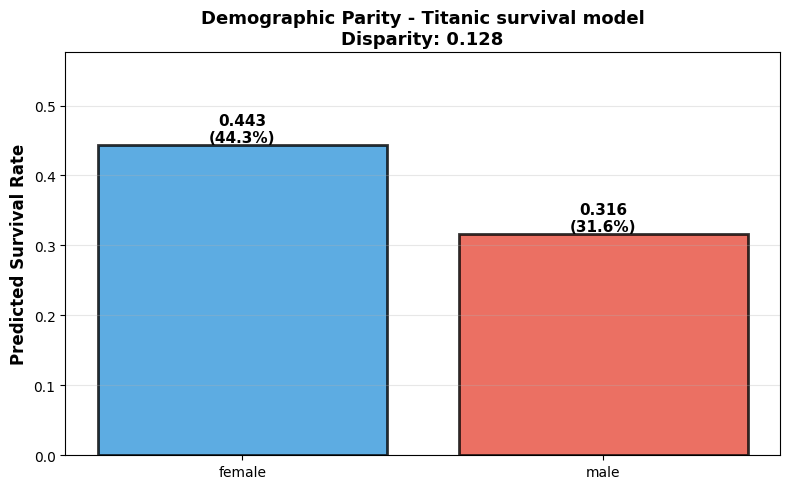

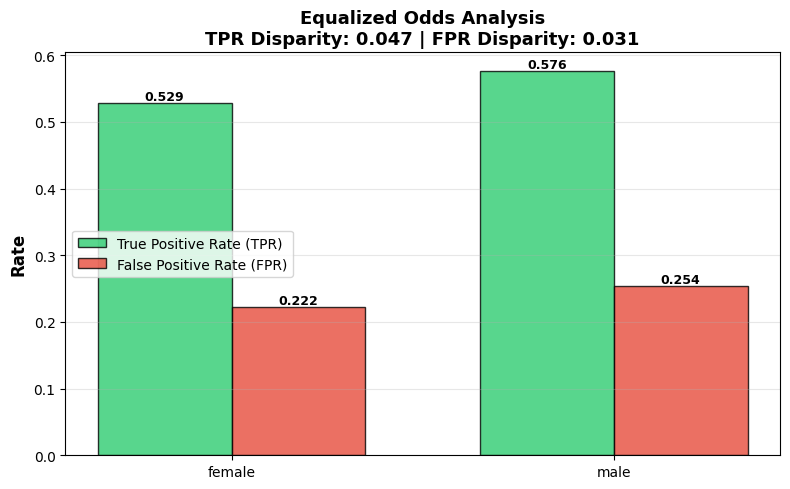

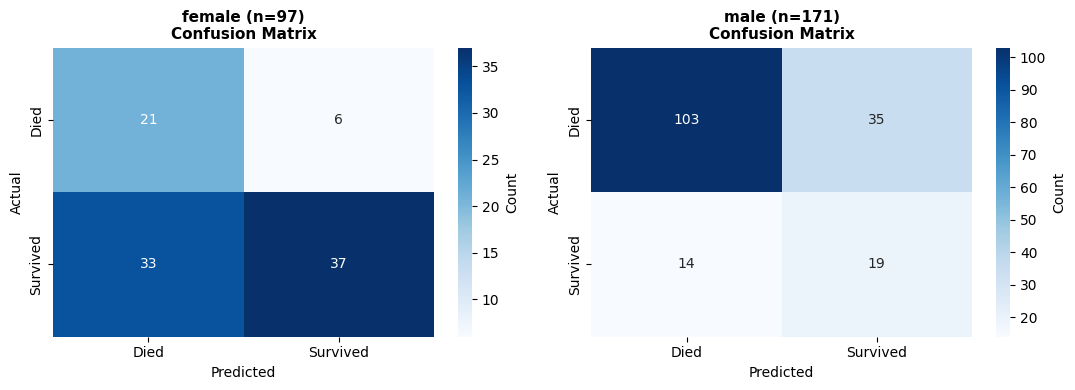

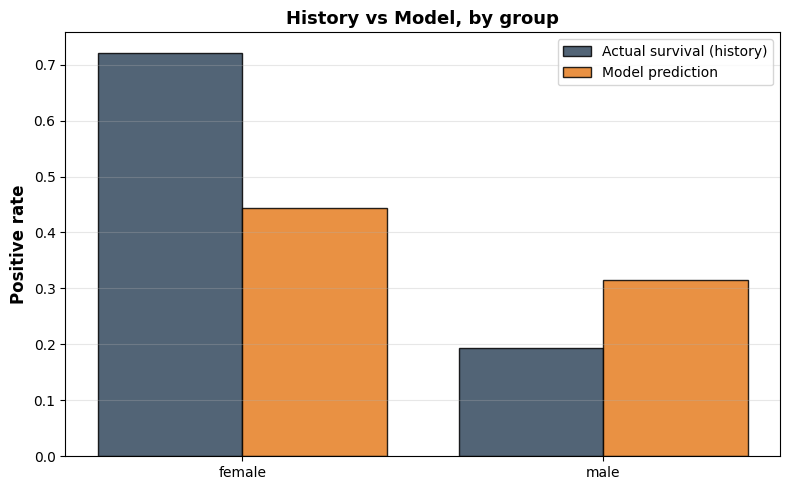

WHAT THE CHARTS ACTUALLY SHOW (numbers computed from this run):
1. The groups receive positive predictions at clearly different rates
   (demographic parity disparity 0.128) - even though the
   model never received the 'Sex' column. Proxies carried the signal.
2. The error profiles are comparatively close (TPR disparity
   0.047, FPR disparity 0.031) - so this model
   is NOT obviously unfair by equalized odds, even though demographic
   parity flagged it. Different metrics, different verdicts.
3. Chart 4 is the uncomfortable one: history recorded 0.722 vs 0.193 survival across the
   two groups, but the blinded model predicted only 0.443 vs 0.316. It UNDER-predicts survival
   for the group that actually survived most - which is exactly why its
   accuracy for that group (0.598) is the worst in the table.

4. THE LESSON: real data does not produce a tidy 'group B is penalized'
   story. Metrics disagreed with each other here. Fairness auditing is
   about reporting several metrics ho

In [5]:
# Step 5: Visualize the bias detection results
# Three views: demographic parity, equalized odds, per-group confusion matrices

# --- Chart 1: Demographic parity ---
groups = list(parity_rates.keys())
rates = list(parity_rates.values())
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(groups, rates, color=['#3498db', '#e74c3c'], alpha=0.8,
              edgecolor='black', linewidth=2)
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{rate:.3f}\n({rate*100:.1f}%)', ha='center', va='bottom',
            fontweight='bold', fontsize=11)
ax.set_ylabel('Predicted Survival Rate', fontsize=12, fontweight='bold')
ax.set_title(f'Demographic Parity - Titanic survival model\nDisparity: {parity_disparity:.3f}',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, max(rates) * 1.3)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# --- Chart 2: Equalized odds ---
tprs = [equalized_odds[g]['TPR'] for g in groups]
fprs = [equalized_odds[g]['FPR'] for g in groups]
x = np.arange(len(groups))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - width/2, tprs, width, label='True Positive Rate (TPR)',
            color='#2ecc71', alpha=0.8, edgecolor='black')
b2 = ax.bar(x + width/2, fprs, width, label='False Positive Rate (FPR)',
            color='#e74c3c', alpha=0.8, edgecolor='black')
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{bar.get_height():.3f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(groups)
ax.set_ylabel('Rate', fontsize=12, fontweight='bold')
ax.set_title(f'Equalized Odds Analysis\nTPR Disparity: {tpr_disparity:.3f} | '
             f'FPR Disparity: {fpr_disparity:.3f}', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# --- Chart 3: Confusion matrices by group ---
uniq = sorted(test_df['group'].unique())
fig, axes = plt.subplots(1, len(uniq), figsize=(11, 4))
for idx, group in enumerate(uniq):
    gd = test_df[test_df['group'] == group]
    cm = confusion_matrix(gd['Survived'], gd['predicted'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                cbar_kws={'label': 'Count'})
    axes[idx].set_title(f'{group} (n={len(gd)})\nConfusion Matrix',
                        fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Predicted'); axes[idx].set_ylabel('Actual')
    axes[idx].set_xticklabels(['Died', 'Survived'])
    axes[idx].set_yticklabels(['Died', 'Survived'])
plt.tight_layout()
plt.show()

# --- Chart 4: what the model was ASKED to predict vs what it DID predict ---
# Real data lets us compare the model's behaviour to the historical record itself.
actual_rate = test_df.groupby('group')['Survived'].mean()
pred_rate = test_df.groupby('group')['predicted'].mean()
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(actual_rate))
ax.bar(x - 0.2, actual_rate.values, 0.4, label='Actual survival (history)',
       color='#34495e', alpha=0.85, edgecolor='black')
ax.bar(x + 0.2, pred_rate.values, 0.4, label='Model prediction',
       color='#e67e22', alpha=0.85, edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(actual_rate.index)
ax.set_ylabel('Positive rate', fontsize=12, fontweight='bold')
ax.set_title('History vs Model, by group', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Data-driven reading of the charts (computed, not assumed):
print("WHAT THE CHARTS ACTUALLY SHOW (numbers computed from this run):")
if parity_disparity > 0.1:
    print(f"1. The groups receive positive predictions at clearly different rates")
    print(f"   (demographic parity disparity {parity_disparity:.3f}) - even though the")
    print(f"   model never received the 'Sex' column. Proxies carried the signal.")
else:
    print(f"1. Overall positive-prediction rates look similar")
    print(f"   (demographic parity disparity only {parity_disparity:.3f}).")

if tpr_disparity > 0.1 or fpr_disparity > 0.1:
    print(f"2. The ERROR profiles also differ (TPR disparity {tpr_disparity:.3f},")
    print(f"   FPR disparity {fpr_disparity:.3f}) - see the confusion matrices.")
else:
    print(f"2. The error profiles are comparatively close (TPR disparity")
    print(f"   {tpr_disparity:.3f}, FPR disparity {fpr_disparity:.3f}) - so this model")
    print(f"   is NOT obviously unfair by equalized odds, even though demographic")
    print(f"   parity flagged it. Different metrics, different verdicts.")

print(f"3. Chart 4 is the uncomfortable one: history recorded "
      f"{actual_rate.max():.3f} vs {actual_rate.min():.3f} survival across the")
print(f"   two groups, but the blinded model predicted only "
      f"{pred_rate.max():.3f} vs {pred_rate.min():.3f}. It UNDER-predicts survival")
print(f"   for the group that actually survived most - which is exactly why its")
print(f"   accuracy for that group ({accs[worst]:.3f}) is the worst in the table.")
print("\n4. THE LESSON: real data does not produce a tidy 'group B is penalized'")
print("   story. Metrics disagreed with each other here. Fairness auditing is")
print("   about reporting several metrics honestly, then arguing about which one")
print("   the situation demands - not about finding a single number that passes.")

## 🎯 Summary: What We Learned

**BEFORE this notebook**: We knew bias exists but didn't know how to detect it in our models.

**AFTER this notebook**: We can:
- ✅ Audit a **real** dataset (891 Titanic passengers) for group disparity
- ✅ Handle real missingness honestly before auditing (and say what we imputed)
- ✅ Calculate fairness metrics (demographic parity, equalized odds, per-group accuracy)
- ✅ Train ML models and detect disparity in their predictions
- ✅ Visualize bias using charts and confusion matrices
- ✅ Interpret bias detection results **when the metrics disagree**

### Key Takeaways

1. **Multiple Metrics Matter**: Different fairness metrics reveal different types of
   disparity - and on real data they routinely return different verdicts on the
   SAME model. Run the cells above and read which ones fired.
2. **Fairness Through Unawareness Fails**: our model never received the `Sex`
   column and still split its predictions by group, because fare, ticket class and
   family size act as proxies. Deleting a protected attribute is not a mitigation.
3. **Report Per Group, Never Only In Aggregate**: the overall accuracy hid a
   clear per-group accuracy gap.
4. **Disparity ≠ Proven Discrimination**: "women and children first" was a stated
   policy. A metric detects that outcomes differ; only human judgment decides
   whether that difference is justified. Real data forces this distinction.
5. **Visualization Helps**: charts make disparity patterns easier to communicate.

---

## 🚫 When Bias Detection Hits a Limitation

### The Limitation We Discovered

We've learned how to detect bias in AI systems using metrics like demographic parity and equalized odds. **But there's a critical problem:**

**We detected disparity, but how do we fix it?**

Bias detection tells us:
- ✅ Where disparity exists
- ✅ How large it is
- ✅ Which groups are affected

**But it doesn't tell us:**
- ❌ How to **reduce** the disparity
- ❌ How to **mitigate** unfairness
- ❌ How to **fix** the model

### Why This Is a Problem

When we detect bias but can't fix it:
- We know there's a problem but can't solve it
- Unfair systems continue to operate
- Affected groups continue to be disadvantaged
- Detection alone isn't enough

### The Solution: Bias Mitigation

We need **bias mitigation techniques** to:
1. Reduce disparity in models
2. Make systems fairer across groups
3. Fix the problems we detected

**This is exactly what we'll learn in the next notebook: Bias Mitigation!**

---

## ➡️ Next Steps

**You've completed this notebook!** Now you understand:
- ✅ How to detect bias using fairness metrics on real data
- ✅ How to visualize disparity patterns
- ✅ **The limitation**: Detection isn't enough - we need to fix it!

**Next notebook**: `02_bias_mitigation.ipynb`
- Learn how to mitigate bias using pre-processing, in-processing, and post-processing
- Work on the SAME real Titanic data, so you can see what actually changes
- Make models fairer across groups

**Congratulations!** 🎉 You've learned how to detect bias in machine learning models systematically!

## 📚 References

1. Dwork, C., Hardt, M., Pitassi, T., Reingold, O. & Zemel, R. (2012). *Fairness Through Awareness*. ITCS 2012. <https://arxiv.org/abs/1104.3913>
2. Hardt, M., Price, E. & Srebro, N. (2016). *Equality of Opportunity in Supervised Learning*. NeurIPS 2016. <https://arxiv.org/abs/1610.02413>
3. Mehrabi, N., Morstatter, F., Saxena, N., Lerman, K. & Galstyan, A. (2021). *A Survey on Bias and Fairness in Machine Learning*. ACM Computing Surveys, 54(6). <https://arxiv.org/abs/1908.09635>
4. Barocas, S., Hardt, M. & Narayanan, A. (2023). *Fairness and Machine Learning: Limitations and Opportunities*. MIT Press. <https://fairmlbook.org/>